In [25]:
import pandas as pd
import numpy as np

# Load base data
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

# Load clusters
kmeans_train = np.load('data/processed/kmeans_train.npy')
kmeans_test = np.load('data/processed/kmeans_test.npy')

dbscan_train = np.load('data/processed/dbscan_train.npy')
dbscan_test = np.load('data/processed/dbscan_test.npy')

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

print(kmeans_train.shape)
print(dbscan_train.shape)

(8844, 30)
(2211, 30)
(8844,)
(2211,)
(8844,)
(8844,)


In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9289914066033469

Classification Report:
               precision    recall  f1-score   support

          -1       0.94      0.90      0.92       980
           1       0.92      0.95      0.94      1231

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211


Confusion Matrix:
 [[ 884   96]
 [  61 1170]]


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9746720940750792

Classification Report:
               precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.99      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.98      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Confusion Matrix:
 [[ 942   38]
 [  18 1213]]


In [29]:
X_train_km = X_train.copy()
X_test_km = X_test.copy()

X_train_km['cluster_kmeans'] = kmeans_train
X_test_km['cluster_kmeans'] = kmeans_test

rf_km = RandomForestClassifier(random_state=42)
rf_km.fit(X_train_km, y_train)

y_pred_km = rf_km.predict(X_test_km)

print("Accuracy:", accuracy_score(y_test, y_pred_km))
print("\nClassification Report:\n", classification_report(y_test, y_pred_km))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_km))

Accuracy: 0.9751243781094527

Classification Report:
               precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.98      2211
   macro avg       0.98      0.97      0.97      2211
weighted avg       0.98      0.98      0.98      2211


Confusion Matrix:
 [[ 945   35]
 [  20 1211]]


In [30]:
X_train_db = X_train.copy()
X_test_db = X_test.copy()

X_train_db['cluster_dbscan'] = dbscan_train
X_test_db['cluster_dbscan'] = dbscan_test

rf_db = RandomForestClassifier(random_state=42)
rf_db.fit(X_train_db, y_train)

y_pred_db = rf_db.predict(X_test_db)

print("Accuracy:", accuracy_score(y_test, y_pred_db))
print("\nClassification Report:\n", classification_report(y_test, y_pred_db))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_db))

Accuracy: 0.9746720940750792

Classification Report:
               precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.98      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Confusion Matrix:
 [[ 944   36]
 [  20 1211]]


In [31]:
X_train_both = X_train.copy()
X_test_both = X_test.copy()

X_train_both['cluster_kmeans'] = kmeans_train
X_train_both['cluster_dbscan'] = dbscan_train

X_test_both['cluster_kmeans'] = kmeans_test
X_test_both['cluster_dbscan'] = dbscan_test


rf_both = RandomForestClassifier(random_state=42)
rf_both.fit(X_train_both, y_train)

y_pred_both = rf_both.predict(X_test_both)

print("Accuracy:", accuracy_score(y_test, y_pred_both))
print("\nClassification Report:\n", classification_report(y_test, y_pred_both))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_both))

Accuracy: 0.9755766621438263

Classification Report:
               precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.98      2211
   macro avg       0.98      0.97      0.98      2211
weighted avg       0.98      0.98      0.98      2211


Confusion Matrix:
 [[ 945   35]
 [  19 1212]]


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_both, y_train)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test_both)

print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Best Params: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.9760289461781999

Classification Report:
               precision    recall  f1-score   support

          -1       0.98      0.97      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.98      2211
   macro avg       0.98      0.97      0.98      2211
weighted avg       0.98      0.98      0.98      2211



100%|===================| 4415/4422 [06:03<00:00]        

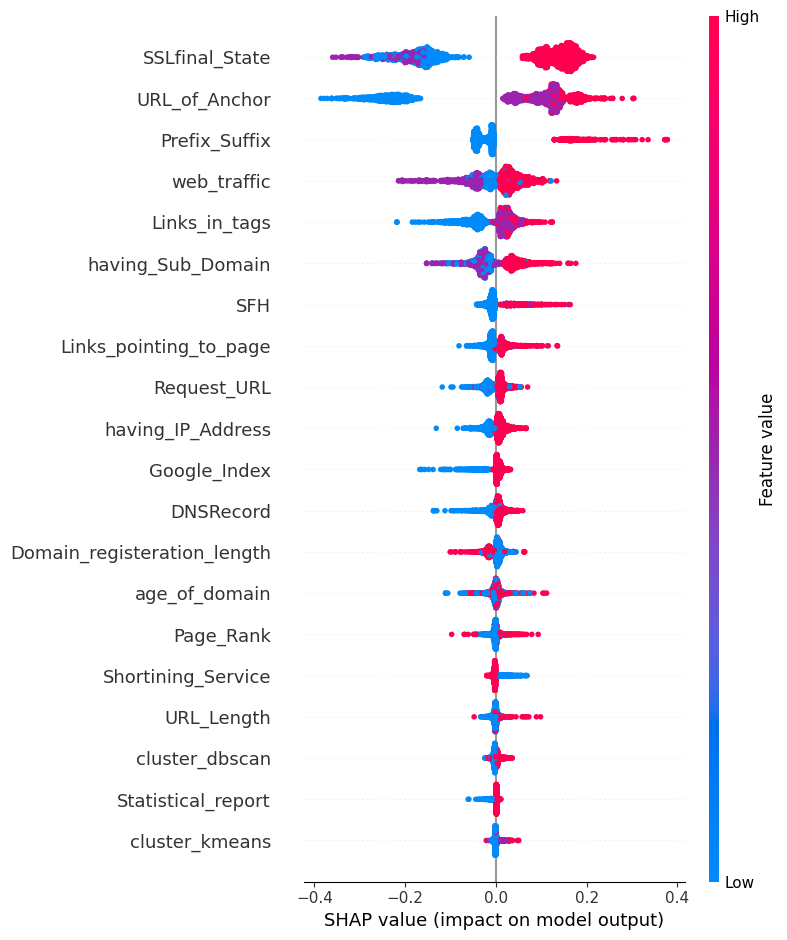

In [36]:
import shap

X_test_both_aligned = X_test_both.copy()
X_test_both_aligned = X_test_both_aligned[best_rf.feature_names_in_]

explainer = shap.Explainer(best_rf, X_test_both)
shap_values = explainer(X_test_both)

shap.summary_plot(shap_values.values[:, :, 1], X_test_both)